# Sales Data Analysis

## Project Overview

This project analyzes supermarket sales data to understand sales performance across branches, cities, product lines, customer types, and genders.

The analysis focuses on identifying sales patterns, comparing customer segments, and understanding differences in sales and tax contributions across different categories.

## Objectives

- Analyze overall sales performance across branches and cities.
- Identify the best-performing product lines.
- Compare sales across customer types and genders.
- Understand sales differences between branches and product categories.
- Analyze tax contribution across different customer and product segments.
- Identify relationships between Unit Price, Quantity, and Tax.

## Tools & Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## Dataset

The dataset contains supermarket sales transactions with information about:

- Branch and City
- Customer Type
- Gender
- Product Line
- Unit Price
- Quantity
- Tax
- Other transaction-related details

The dataset is used to analyze sales performance and identify patterns across different customer and product segments.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
df = pd.read_csv("C:/Users/LENOVO/Desktop/Sales_report/Data/supermarket_sales new.csv")

## 1. Data Overview
This section provides an initial understanding of the dataset, including its dimensions, columns, data types, statistical summary, and sample records.

In [4]:
# Check the number of rows and columns
df.shape

(1000, 9)

In [5]:
# Check the columns name
df.columns

Index(['Gender', 'Invoice ID', 'Branch', 'City', 'Customer type',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%'],
      dtype='str')

In [6]:
# Generate statistical summary of numerical columns
df.describe()

,Unit price,Quantity,Tax 5%
count,1000.000000,1000.000000,1000.000000
mean,55.672130,5.510000,43.911392
std,26.494628,2.923431,100.551612
min,10.080000,1.000000,1.066000
25%,32.875000,3.000000,6.222500
50%,55.230000,5.000000,12.404000
75%,77.935000,8.000000,27.226250
max,99.960000,10.000000,985.000000


In [7]:
# Check data types and non-null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Gender         1000 non-null   str    
 1   Invoice ID     1000 non-null   str    
 2   Branch         1000 non-null   str    
 3   City           1000 non-null   str    
 4   Customer type  1000 non-null   str    
 5   Product line   1000 non-null   str    
 6   Unit price     1000 non-null   float64
 7   Quantity       1000 non-null   int64  
 8   Tax 5%         1000 non-null   float64
dtypes: float64(2), int64(1), str(6)
memory usage: 70.4 KB


In [8]:
# View the first five rows
df.head()

,Gender,Invoice ID,Branch,City,Customer type,Product line,Unit price,Quantity,Tax 5%
0,Female,750-67-8428,A,Yangon,Member,Health and beauty,74.69,7,261.415
1,Female,226-31-3081,C,Naypyitaw,Normal,Electronic accessories,15.28,5,3.820
2,Female,355-53-5943,A,Yangon,Member,Electronic accessories,68.84,6,20.652
3,Female,315-22-5665,C,Naypyitaw,Normal,Home and lifestyle,73.56,10,36.780
4,Female,665-32-9167,A,Yangon,Member,Health and beauty,36.26,2,3.626


## 2. Data Cleaning
The dataset is checked for missing values, duplicate records, and appropriate data types before performing further analysis.

In [9]:
# Check for missing values
df.isnull().sum()

Gender           0
Invoice ID       0
Branch           0
City             0
Customer type    0
Product line     0
Unit price       0
Quantity         0
Tax 5%           0
dtype: int64

### Observation

There are no missing values in the dataset, so no missing-value treatment is required.

In [10]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

### Observation

The dataset contains no duplicate rows.

## 3. Feature Creation

To analyze sales performance, a Total Sales column is created by multiplying Unit price by Quantity.

In [11]:
# Calculate total sales for each transaction
df["Total_sales"] = df["Unit price"] * df["Quantity"]

In [12]:
# View the updated dataset
df.head()

,Gender,Invoice ID,Branch,City,Customer type,Product line,Unit price,Quantity,Tax 5%,Total_sales
0,Female,750-67-8428,A,Yangon,Member,Health and beauty,74.69,7,261.415,522.83
1,Female,226-31-3081,C,Naypyitaw,Normal,Electronic accessories,15.28,5,3.820,76.40
2,Female,355-53-5943,A,Yangon,Member,Electronic accessories,68.84,6,20.652,413.04
3,Female,315-22-5665,C,Naypyitaw,Normal,Home and lifestyle,73.56,10,36.780,735.60
4,Female,665-32-9167,A,Yangon,Member,Health and beauty,36.26,2,3.626,72.52


## Analysis

Exploratory Data Analysis (EDA) was performed to understand sales patterns across branches, cities, product lines, customer types, and genders.

In [13]:
df.head()

,Gender,Invoice ID,Branch,City,Customer type,Product line,Unit price,Quantity,Tax 5%,Total_sales
0,Female,750-67-8428,A,Yangon,Member,Health and beauty,74.69,7,261.415,522.83
1,Female,226-31-3081,C,Naypyitaw,Normal,Electronic accessories,15.28,5,3.820,76.40
2,Female,355-53-5943,A,Yangon,Member,Electronic accessories,68.84,6,20.652,413.04
3,Female,315-22-5665,C,Naypyitaw,Normal,Home and lifestyle,73.56,10,36.780,735.60
4,Female,665-32-9167,A,Yangon,Member,Health and beauty,36.26,2,3.626,72.52


### 4.1 Transactions by City

In [14]:
# Count the number of transactions in each city

city_count = df["City"].value_counts()

### 4.2 Transactions by Customer Type

In [15]:
Customer_type_count = df["Customer type"].value_counts()

### 4.3 Transactions by Product Line

In [16]:
Product_line_count = df["Product line"].value_counts()

### 4.4 Total Sales by Branch

In [17]:
total_branch_sales = df.groupby("Branch")["Total_sales"].sum()

### 4.5 Total Sales by Product Line

In [18]:
product_line_sales = df.groupby("Product line")["Total_sales"].sum()

### 4.6 Total sales by gender 

In [19]:
total_gender_sales = df.groupby('Gender')['Total_sales'].sum()

### 4.7 Sales by branch and product line 

Branch C records the highest sales for several product lines, particularly Food and Beverages and Fashion Accessories. Branch A performs strongly in Home and Lifestyle, while Branch B performs relatively well in Health and Beauty and Sports and Travel.

In [20]:
Branch_sales = df.groupby(["Branch","Product line"])['Total_sales'].sum().reset_index()

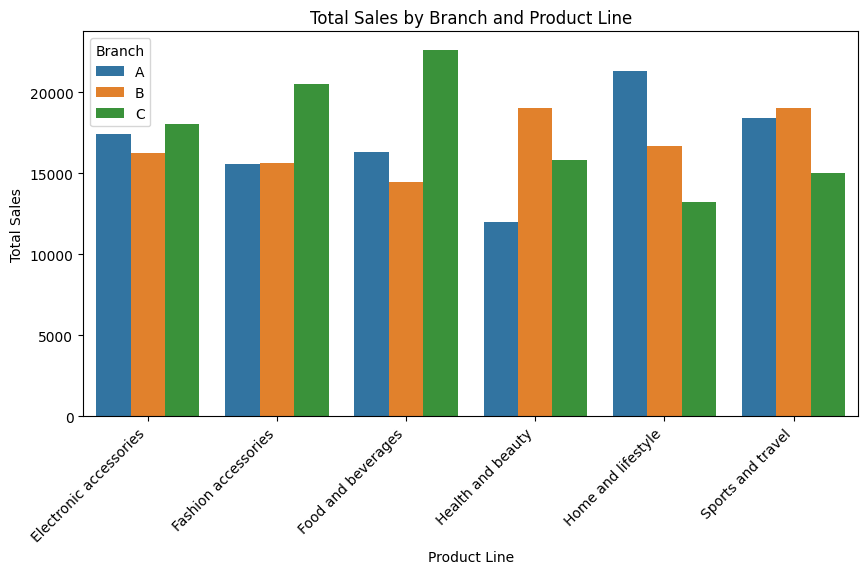

In [21]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=Branch_sales,
    x="Product line",
    y="Total_sales",
    hue="Branch"
)

plt.title("Total Sales by Branch and Product Line")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")

plt.show()

### 4.8 Total sales by product line

Sports and Travel generates the highest total sales among the product lines, followed by Food and Beverages and Fashion Accessories. Health and Beauty has the lowest total sales.

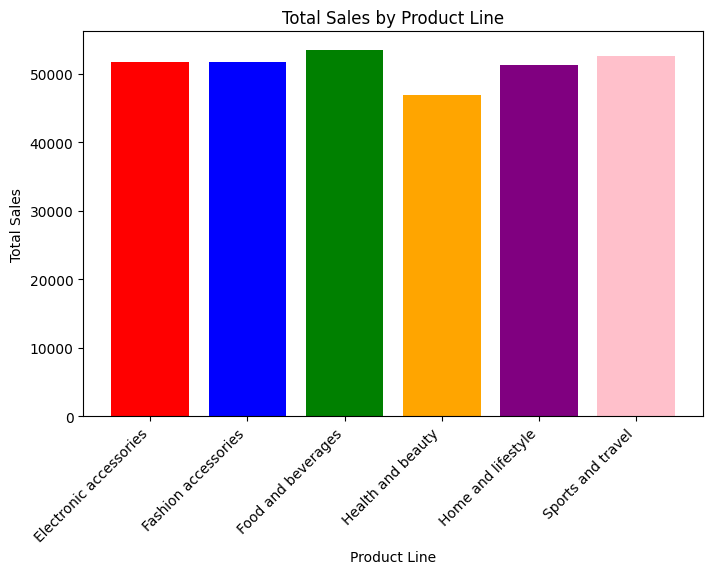

In [22]:
plt.figure(figsize=(8,5))

plt.bar(product_line_sales.index, product_line_sales.values,
            color=["red", "blue", "green", "orange", "purple", "pink"]
)
plt.title("Total Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")

plt.xticks(rotation=45, ha="right")

plt.show()

### 4.9 — Total sales by customer type

Member customers generate slightly higher total sales than Normal customers, indicating that both customer groups contribute substantially to overall sales.


In [23]:
Customer_type_sales = df.groupby("Customer type")["Total_sales"].sum()
Customer_type_sales

Customer type
Member    156403.28
Normal    151184.10
Name: Total_sales, dtype: float64

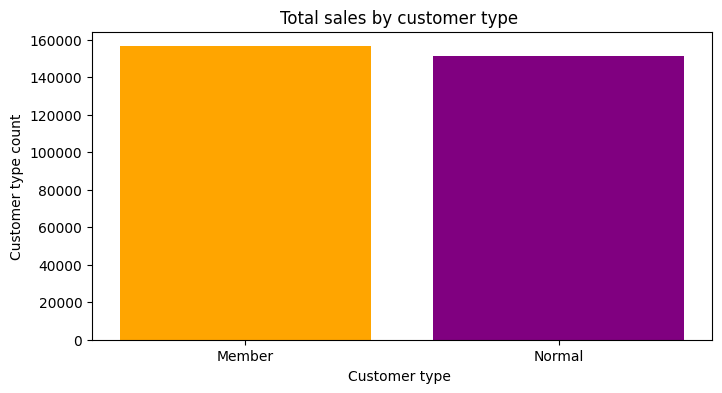

In [24]:
plt.figure(figsize=(8,4))
plt.bar(Customer_type_sales.index,Customer_type_sales.values,color=["orange","purple"])
plt.title("Total sales by customer type ")
plt.xlabel("Customer type ")
plt.ylabel("Customer type count")
plt.show()

### 4.10 Total sales by gender

Female customers generate higher total sales than male customers in the dataset, indicating a higher overall sales contribution from female customers.

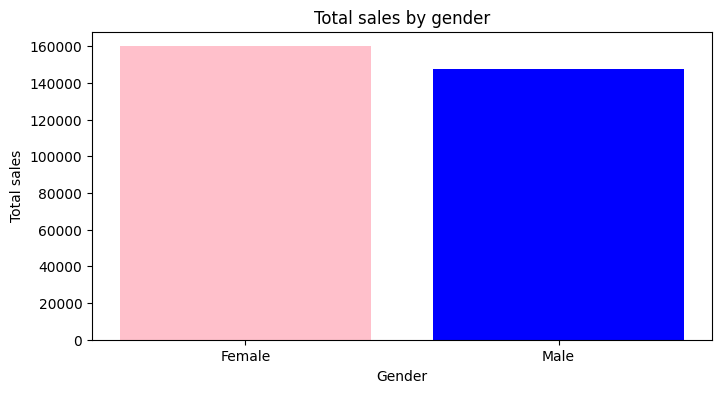

In [25]:
plt.figure(figsize=(8,4))
plt.bar(total_gender_sales.index,total_gender_sales.values,color=["pink","blue"])
plt.title("Total sales by gender")
plt.xlabel("Gender")
plt.ylabel("Total sales")
plt.show()

### 4.11 Total sales by city

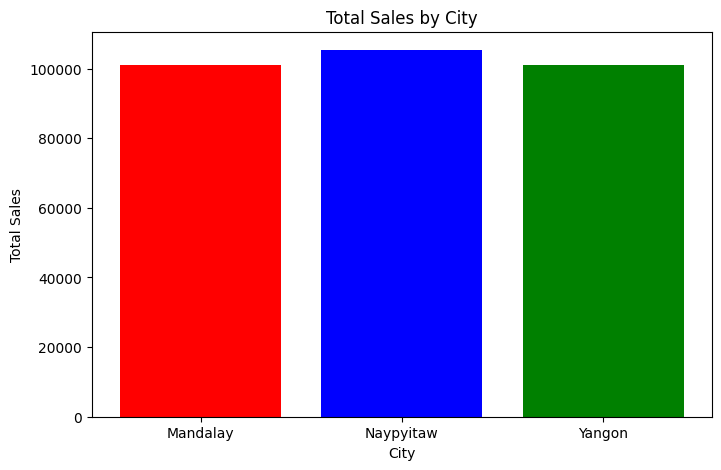

In [26]:
city_sales = df.groupby("City")["Total_sales"].sum()

plt.figure(figsize=(8,5))

plt.bar(
    city_sales.index,
    city_sales.values,
    color=["red", "blue", "green"]
)

plt.title("Total Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")

plt.show()

### 4.12 Total sales by branch

Branch C has the highest total sales, while Branch A and Branch B have very similar sales performance.

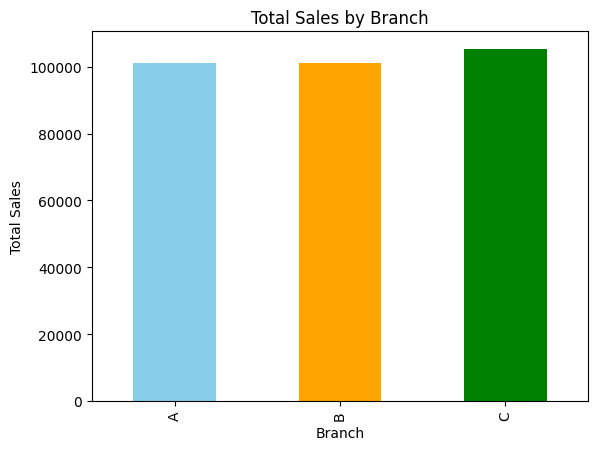

In [27]:
total_branch_sales = df.groupby("Branch")["Total_sales"].sum()

total_branch_sales.plot(kind="bar",
                            color=["skyblue", "orange", "green"])
plt.xlabel("Branch")
plt.ylabel("Total Sales")
plt.title("Total Sales by Branch")
plt.show()

### 4.13 — Total Tax by Gender and Product Line

The total tax contribution varies across product lines and genders. Fashion Accessories has the highest tax contribution for both female and male customers, while Food and Beverages shows a relatively large difference between female and male tax contributions.

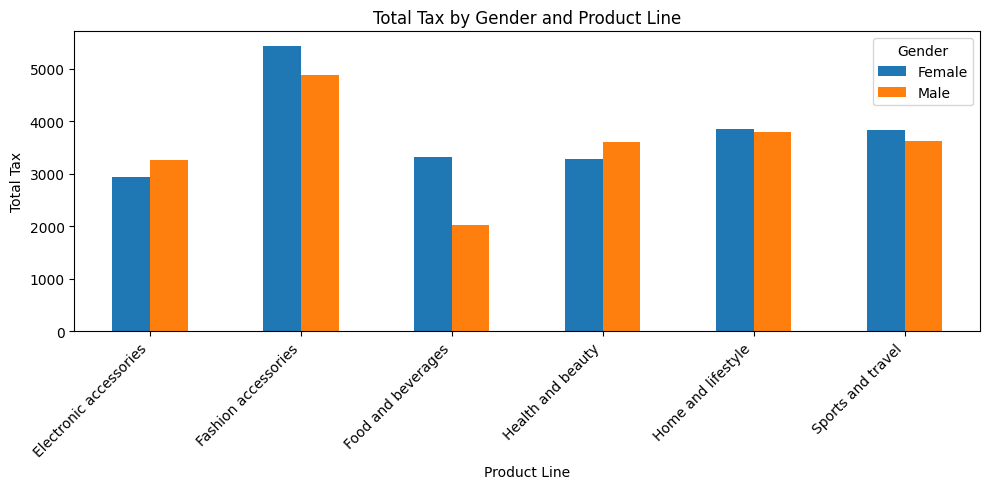

In [28]:
Gender_product = df.groupby(['Product line', 'Gender'])['Tax 5%'].sum().unstack()

Gender_product.plot(kind='bar', figsize=(10,5))

plt.title('Total Tax by Gender and Product Line')
plt.xlabel('Product Line')
plt.ylabel('Total Tax')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4.14 Total tax by customer type and product line

Fashion Accessories generates the highest total tax for both Member and Normal customers. Among Member customers, Health and Beauty and Home and Lifestyle also contribute relatively high tax amounts, while Normal customers show a particularly high tax contribution from Sports and Travel.

In [29]:
Customer_product = df.groupby(['Customer type', 'Product line'])['Tax 5%'].sum().unstack()

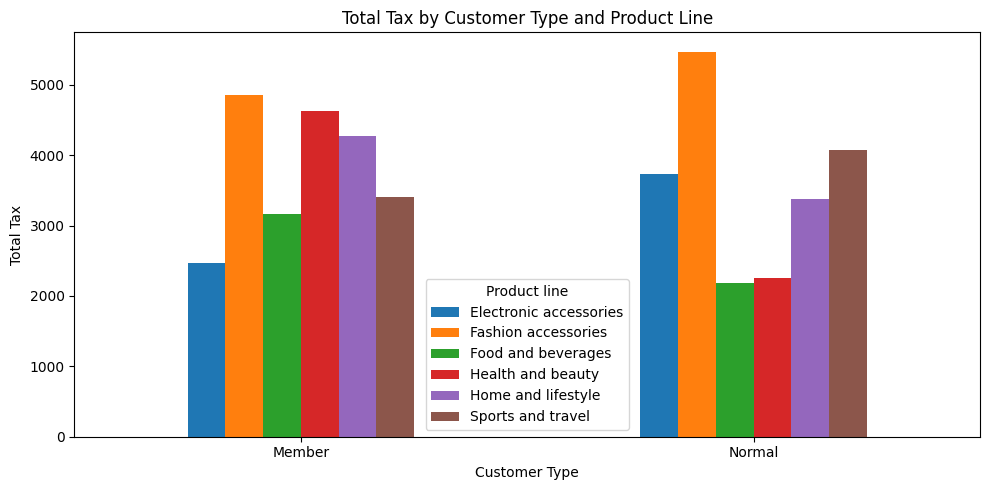

In [30]:
Customer_product.plot(kind='bar', figsize=(10,5))

plt.title('Total Tax by Customer Type and Product Line')
plt.xlabel('Customer Type')
plt.ylabel('Total Tax')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.15 Correlation between unit price, quantity, tax

Unit Price and Quantity have almost no correlation, with a correlation of approximately 0.011. Tax has a weak positive correlation with both Unit Price and Quantity. Overall, the variables do not show a strong linear relationship.

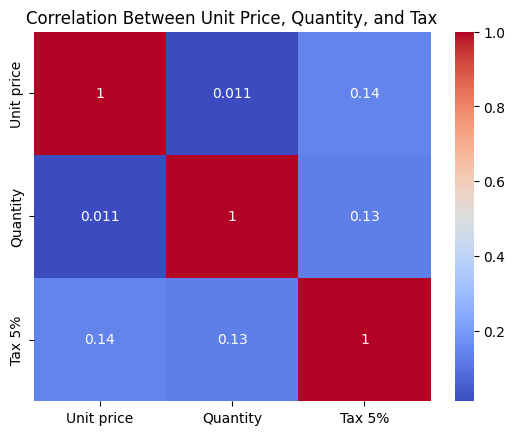

In [31]:
sns.heatmap(df[['Unit price', 'Quantity', 'Tax 5%']].corr(),
        annot=True,cmap='coolwarm')
plt.title('Correlation Between Unit Price, Quantity, and Tax')
plt.show()

## Key Insights

## 5. Recommendations

- Focus on the better-performing product lines and monitor their sales performance regularly.
- Review the performance of lower-performing product lines to understand opportunities for improvement.
- Compare branch-level performance to identify successful sales patterns that could be applied across other branches.
- Continue monitoring Member and Normal customer sales separately to understand customer purchasing patterns.
- Use gender-based sales patterns as a supporting factor when evaluating customer preferences and marketing strategies.
- Monitor tax contributions across product lines and customer segments as part of financial reporting.
- Use the findings from this analysis as a starting point for deeper analysis of customer behavior, product demand, and branch performance.

## 6. Conclusion

The analysis provides an overview of sales performance across different branches, cities, product lines, customer types, and genders.

The results show that sales performance varies across product lines and branches, with some categories contributing more strongly to total sales than others. Member customers contribute slightly higher total sales than Normal customers, while female customers contribute higher total sales than male customers.

The analysis also shows differences in tax contribution across product lines, customer types, and genders. The correlation analysis indicates that Unit Price and Quantity have almost no linear relationship, while Tax has only a weak positive relationship with both variables.

Overall, the analysis helps identify important sales patterns and areas that can be considered when making business decisions.